In [1]:
import libPoisson as lb
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
eps = 4.0
solver = lb.NBody(permittivity=eps, charge_radius=0.1, periodicityX="open", periodicityY="open", periodicityZ="open")
# Create a charge in the center of the domain
n_sources = 1
n_targets = int(1e7)
source_pos = cp.array([[0.0, 0.0, 0.0]]*n_sources).flatten()
source_charge = cp.array([1.0]*n_sources)
target_x = cp.linspace(-1.0, 1.0, n_targets)
target_y = cp.zeros_like(target_x)
target_z = cp.zeros_like(target_x)
target_pos = cp.stack((target_x, target_y, target_z), axis=-1).flatten()

phi, E = solver(source_pos, target_pos, source_charge)
print("Potential at x=0.1: ", phi[int(n_targets/2)].get())
x = target_pos.reshape(-1,3)[:,0].get()
Ex = E.reshape(-1,3)[:,0].get()
plt.plot(x, phi.get(), '-', label='Potential')
plt.plot(x, n_sources*np.sign(x)/(4*np.pi*eps*x), 'r--', label='1/x')
plt.vlines(0.1, np.min(Ex)*1.1, np.max(Ex)*1.1, colors='k', linestyles='dashed')
plt.ylim(0, np.max(phi.get())*1.1)
plt.xlabel('x')
plt.ylabel('Potential')
plt.title('Potential along x-axis')
plt.legend()
plt.show()

Potential at x=0.1:  0.27493550848832843


KeyboardInterrupt: 

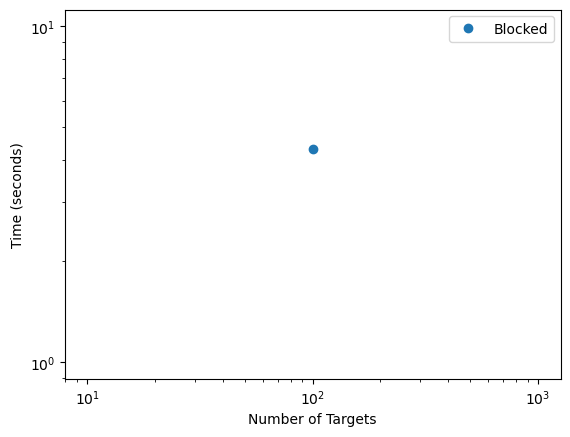

In [4]:
# check performance
import libPoisson as lb
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import time
timer_blocked = []
timer_unblocked = []
samples = 1
N_SAMPLES = np.logspace(5, 5, num=1, dtype=int)
n_targets = 1
eps = 4.0
solver_blocked = lb.NBody(permittivity=eps, charge_radius=0.1, periodicityX="open", periodicityY="open", periodicityZ="open")
n_sources = N_SAMPLES[-1]
source_pos = cp.array([[0.0, 0.0, 0.0]]*n_sources).flatten()
source_charge = cp.array([1.0]*n_sources)
target_x = cp.linspace(-1.0, 1.0, n_targets)
target_y = cp.zeros_like(target_x)
target_z = cp.zeros_like(target_x)
target_pos = cp.stack((target_x, target_y, target_z), axis=-1).flatten()
for n_sources in N_SAMPLES:
    blocked = 0
    unblocked = 0
    for _ in range(samples):
        a = time.time()
        #phi, E = solver(source_pos, target_pos, source_charge)
        unblocked += time.time() - a
        a = time.time()
        solver_blocked(source_pos, source_pos, source_charge)
        cp.cuda.Stream.null.synchronize()
        blocked += time.time() - a
    timer_blocked.append(blocked/samples)
    timer_unblocked.append(unblocked/samples)
#plt.plot(N_SAMPLES, timer_unblocked, label="Unblocked")
plt.plot(np.logspace(2,5,num=1, dtype=int),timer_blocked,'o', label="Blocked")
plt.xlabel("Number of Targets")
plt.ylabel("Time (seconds)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()